In [193]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [194]:
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)


In [195]:
# Default Logistic Regression Model
logreg = LogisticRegression()
logreg.fit(X_train, y_train)


LogisticRegression()

In [196]:
print("Training set Score: {:.3f}".format(logreg.score(X_train,y_train)))
print("Testing set Score: {:.3f}".format(logreg.score(X_test, y_test)))

Training set Score: 0.944
Testing set Score: 0.958


The default value of C=1 provides quite good performance, with 95% accuracy on both the training and the test set. But as training and test set performance are very close, it is likely that we are underfitting(Since Logistic Regression use regularization reducing regularization might increase the model perform more).

In [197]:
# Logistic Regression Model with C=100
logreg100=LogisticRegression(C=100)
logreg100.fit(X_train, y_train)

LogisticRegression(C=100)

In [198]:
print("Training set Score: {:.3f}".format(logreg100.score(X_train, y_train)))
print("Testing set Score: {:.3f}".format(logreg100.score(X_test, y_test)))

Training set Score: 0.951
Testing set Score: 0.958


Using C=100 results in higher training set accuracy, and also a slightly increased test set accuracy, confirming our intuition that a more complex model should perform better.

Below model shows what happens if we use an even more regularized model than the default of C=1, by setting C=0.01

In [199]:
# Logistic Regression Model with C=0.01
logreg001 = LogisticRegression(C=0.01)
logreg001.fit(X_train, y_train)

LogisticRegression(C=0.01)

In [200]:
print("Training set Score: {:.3f}".format(logreg001.score(X_train, y_train)))
print("Testing set Score: {:.3f}".format(logreg001.score(X_test, y_test)))

Training set Score: 0.937
Testing set Score: 0.930


As expected decreasing the C decreased training and test set accuracy.

Below Figure shows the coefficients learned by the models with the three different settings of the regularization parameter C

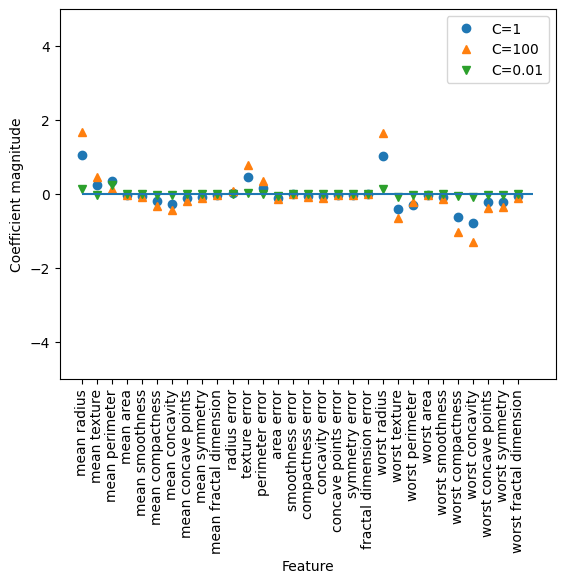

In [201]:
plt.plot(logreg.coef_.T, 'o', label="C=1")
plt.plot(logreg100.coef_.T, '^', label="C=100")
plt.plot(logreg001.coef_.T, 'v', label="C=0.01")
plt.xticks(range(cancer.data.shape[1]), cancer.feature_names, rotation=90)
plt.hlines(0, 0, cancer.data.shape[1])
plt.ylim(-5, 5)
plt.xlabel("Feature")
plt.ylabel("Coefficient magnitude")
plt.legend()

If we want a model that is easier to understand, L1 regularization helps because it automatically ignores unimportant features and keeps only a small number of important ones.

Below is the  coefficient plot and classification accuracies for L1 regularization.

**Note:** L1 regularization is not supported by the default lbfgs solver in LogisticRegression. When using penalty="l1", a compatible solver such as liblinear or saga must be specified explicitly. Otherwise, scikit-learn raises an error.


Training accuracy of l1 logreg with C=0.010: 0.92
Test accuracy of l1 logreg with C=0.010: 0.93
Training accuracy of l1 logreg with C=1.000: 0.96
Test accuracy of l1 logreg with C=1.000: 0.96
Training accuracy of l1 logreg with C=100.000: 0.99
Test accuracy of l1 logreg with C=100.000: 0.98


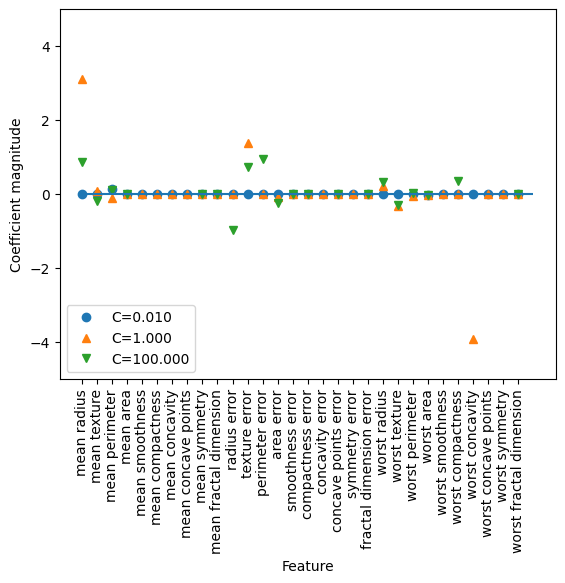

In [202]:
for C, marker in zip([0.01, 1, 100], ['o', '^', 'v']):
    lr_l1 = LogisticRegression(C=C, penalty="l1", solver='liblinear').fit(X_train, y_train)
    print("Training accuracy of l1 logreg with C={:.3f}: {:.2f}".format(
          C, lr_l1.score(X_train, y_train)))
    print("Test accuracy of l1 logreg with C={:.3f}: {:.2f}".format(
          C, lr_l1.score(X_test, y_test)))
    plt.plot(lr_l1.coef_.T, marker, label="C={:.3f}".format(C))

plt.xticks(range(cancer.data.shape[1]), cancer.feature_names, rotation=90)
plt.hlines(0, 0, cancer.data.shape[1])
plt.xlabel("Feature")
plt.ylabel("Coefficient magnitude")

plt.ylim(-5, 5)
plt.legend(loc=3)

As we can see, Linear models for classification and regression work in very similar ways.
The main difference between them comes from the penalty (regularization) parameter, which controls how complex the model is and whether it uses all features or only a few important ones.